In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

# Evita errores de joblib/loky en Windows al detectar núcleos físicos.
# Debe ejecutarse antes de llamar algoritmos de sklearn que paralelizan internamente.
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_squared_error,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation, UnitaryGate, phase_estimation
from qiskit.quantum_info import DensityMatrix, partial_trace, Pauli
from qiskit.visualization import plot_bloch_vector

RANDOM_STATE = 42
np.set_printoptions(precision=5, suppress=True)


## 1. Carga del dataset

La función `load_dataset()` deja aislada la carga de datos. Para cambiar Wine en el futuro, basta con modificar esta función y mantener la salida `(X, y, feature_names, target_name)`.

In [2]:
def load_dataset():
    cancer = fetch_ucirepo(id=17) # Changed from id=109 (Wine) to id=17 (Breast Cancer Wisconsin (Diagnostic))
    X = cancer.data.features.copy()
    y = cancer.data.targets.iloc[:, 0].to_numpy()
    feature_names = list(X.columns)
    target_name = cancer.data.targets.columns[0]
    return X, y, feature_names, target_name

X_df, y, feature_names, target_name = load_dataset()
X_raw = X_df.to_numpy(dtype=float)

print('Dataset:', X_raw.shape)
print('Target:', target_name)
print('Clases:', np.unique(y))
X_df.head()

Dataset: (569, 30)
Target: Diagnosis
Clases: ['B' 'M']


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Preprocesamiento consistente

Todos los métodos parten de los mismos datos estandarizados. Para amplitude encoding, además se aplica padding hasta la siguiente potencia de 2 y normalización L2 por muestra.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

def next_power_of_two(n):
    return 1 if n <= 1 else 2 ** math.ceil(math.log2(n))

def pad_to_dimension(X, target_dim):
    X_padded = np.zeros((X.shape[0], target_dim), dtype=float)
    X_padded[:, : X.shape[1]] = X
    return X_padded

def normalize_rows(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms

amplitude_dim = next_power_of_two(X_scaled.shape[1])
n_system_qubits = int(math.log2(amplitude_dim))

X_padded = pad_to_dimension(X_scaled, amplitude_dim)
X_amp = normalize_rows(X_padded)

print('Dimensión original:', X_scaled.shape[1])
print('Dimensión amplitude encoding:', amplitude_dim)
print('Qubits de sistema:', n_system_qubits)
print('Norma primera muestra:', np.linalg.norm(X_amp[0]))


Dimensión original: 30
Dimensión amplitude encoding: 32
Qubits de sistema: 5
Norma primera muestra: 1.0


## 4. PCA clásico para t-SNE

In [4]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# Instantiate PCA with all possible components to evaluate explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Find the number of components that explain at least 95% of the variance
cum_variance_ratio = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95_var = np.where(cum_variance_ratio >= 0.95)[0][0] + 1

# Limit the number of components for t-SNE to a maximum of 8 or the 95% variance threshold
PCA_COMPONENTS_FOR_TSNE = min(10, n_components_95_var, X_scaled.shape[1])

# PCA clásico con el número de componentes determinado
pca = PCA(n_components=PCA_COMPONENTS_FOR_TSNE, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Para calcular el MSE de reconstrucción de PCA
X_pca_reconstructed = pca.inverse_transform(X_pca)
pca_variance = pca.explained_variance_ratio_.sum()
pca_mse = mean_squared_error(X_scaled, X_pca_reconstructed)

print(f'PCA clásico: Se usaron {PCA_COMPONENTS_FOR_TSNE} componentes.')
print(f'Varianza explicada por PCA clásico: {pca_variance:.4f}')
print(f'MSE de reconstrucción de PCA clásico: {pca_mse:.4f}')

PCA clásico: Se usaron 10 componentes.
Varianza explicada por PCA clásico: 0.9516
MSE de reconstrucción de PCA clásico: 0.0484


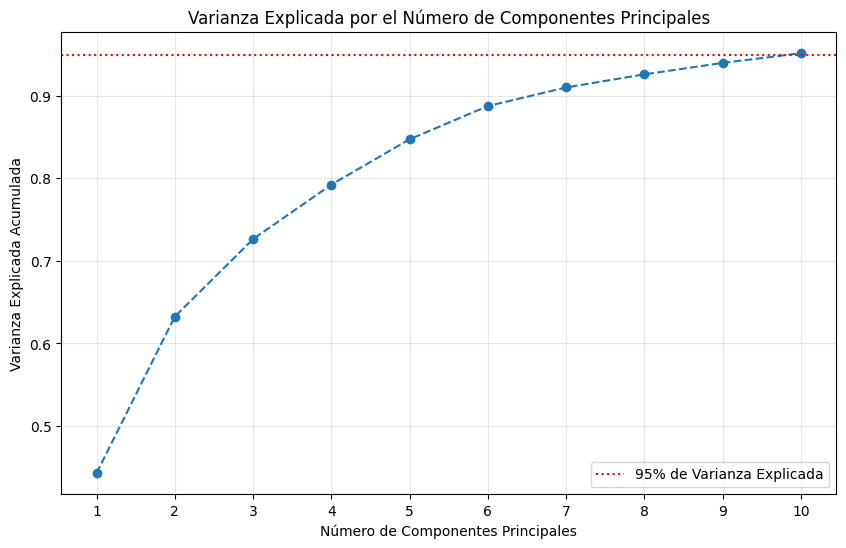

In [5]:
import matplotlib.pyplot as plt

# Calcular la varianza explicada acumulada
cum_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_variance_ratio) + 1), cum_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por el Número de Componentes Principales')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(cum_variance_ratio) + 1))
plt.axhline(y=0.95, color='r', linestyle=':', label='95% de Varianza Explicada')
plt.legend()
plt.show()

Este gráfico muestra cómo la varianza explicada acumulada aumenta a medida que se añaden más componentes principales. Puedes observar dónde la curva empieza a aplanarse, lo que indica que añadir más componentes ya no aporta mucha más información. La línea roja punteada indica el 95% de la varianza explicada, un umbral común para decidir cuántos componentes conservar.

In [6]:
def run_tsne(X, metric='euclidean', perplexity=30, init='pca'):
    if perplexity is None:
        perplexity = min(30, max(5, (X.shape[0] - 1) // 3))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        metric=metric,
        init=init,
        learning_rate='auto',
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    return tsne.fit_transform(X)

## 5. t-SNE sobre datos reducidos por PCA clásico

In [7]:
from sklearn.manifold import TSNE

# t-SNE + PCA clásico
# La perplejidad se configura automáticamente en run_tsne
embedding_tsne_pca = run_tsne(X_pca, metric='euclidean', init='pca')

print('Embedding generado para t-SNE + PCA clásico:', embedding_tsne_pca.shape)

Embedding generado para t-SNE + PCA clásico: (569, 2)


## 6. Tabla de métricas y evaluación

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score

def embedding_metrics(embedding, labels):
    return {
        'Silhouette': silhouette_score(embedding, labels),
        'Harabach': calinski_harabasz_score(embedding, labels),
    }

results = []

def add_result(config, components, depth, width, variance, mse, embedding):
    metrics = embedding_metrics(embedding, y)
    results.append({
        'Configuración': config,
        'Componentes': components,
        'Profundidad': depth,
        'Ancho': width,
        'Varianza': variance,
        'MSE': mse,
        'Silhouette': metrics['Silhouette'],
        'Harabach': metrics['Harabach'],
    })

# Añadir resultado para t-SNE + PCA clásico
add_result('t-SNE + PCA clásico', PCA_COMPONENTS_FOR_TSNE, np.nan, np.nan, pca_variance, pca_mse, embedding_tsne_pca)

comparison_df = pd.DataFrame(results)
comparison_df_rounded = comparison_df.copy()
for col in ['Varianza', 'MSE', 'Silhouette', 'Harabach']:
    comparison_df_rounded[col] = comparison_df_rounded[col].astype(float).round(5)

display(comparison_df_rounded)

,Configuración,Componentes,Profundidad,Ancho,Varianza,MSE,Silhouette,Harabach
0,t-SNE + PCA clásico,10,NaN,NaN,0.95157,0.04843,0.51137,827.04834


## 7. Visualización del Embedding `t-SNE + PCA clásico`

## 9. Experimentación con Parámetros de t-SNE

Vamos a ejecutar t-SNE nuevamente con un conjunto diferente de parámetros para ver cómo afecta la visualización y las métricas de clustering. En este caso, usaremos una perplejidad menor y una inicialización aleatoria para observar el impacto.

## 8. Circuito Cuántico con Qiskit: Ancho y Profundidad

Para entender la complejidad de un circuito cuántico, dos métricas clave son su **ancho** y su **profundidad**.

*   **Ancho (Width):** Se refiere al número de cúbits en el circuito. Un mayor ancho significa que el circuito requiere más recursos cuánticos (cúbits).
*   **Profundidad (Depth):** Es el número de capas de puertas cuánticas en el circuito, ignorando las operaciones clásicas y las mediciones. Una mayor profundidad implica que el circuito es más largo y, por lo tanto, puede ser más susceptible al ruido en los cúbits reales.

In [9]:
# Definir un circuito cuántico de ejemplo para demostrar ancho y profundidad
# Usaremos un circuito simple de 3 cúbits y algunas puertas comunes.

qc = QuantumCircuit(3, 3) # 3 cúbits, 3 bits clásicos

# Añadir algunas puertas al circuito
qc.h(0) # Puerta Hadamard en el cúbit 0
qc.cx(0, 1) # Puerta CNOT con cúbit 0 como control y 1 como objetivo
qc.ry(np.pi/2, 2) # Puerta RY en el cúbit 2
qc.cx(1, 2) # Puerta CNOT con cúbit 1 como control y 2 como objetivo
qc.measure([0,1,2], [0,1,2]) # Medir todos los cúbits

print("Circuito Cuántico de Ejemplo:")
print(qc.draw(output='text'))

Circuito Cuántico de Ejemplo:
        ┌───┐             ┌─┐      
q_0: ───┤ H ├─────■───────┤M├──────
        └───┘   ┌─┴─┐     └╥┘┌─┐   
q_1: ───────────┤ X ├──■───╫─┤M├───
     ┌─────────┐└───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ┤ Ry(π/2) ├─────┤ X ├─╫──╫─┤M├
     └─────────┘     └───┘ ║  ║ └╥┘
c: 3/══════════════════════╩══╩══╩═
                           0  1  2 


In [10]:
# Calcular y mostrar el ancho y la profundidad del circuito
circuit_width = qc.num_qubits
circuit_depth = qc.depth()

print(f"Ancho del circuito (número de cúbits): {circuit_width}")
print(f"Profundidad del circuito (número de capas de puertas): {circuit_depth}")

# Para las métricas de rendimiento, podríamos querer añadir estos valores
# a la tabla de comparación si fuesen circuitos cuánticos reales para embedding.
# Por ahora, solo se muestran como ejemplo.

Ancho del circuito (número de cúbits): 3
Profundidad del circuito (número de capas de puertas): 4


In [11]:
# Definir un rango de valores de perplejidad a probar
perplexity_values = [30, 40, 50, 60, 70]

print("Ejecutando t-SNE con diferentes perplejidades...")

for p in perplexity_values:
    print(f"  - Perplejidad: {p}")
    embedding_tsne_pca_p = run_tsne(X_pca, metric='euclidean', perplexity=p, init='pca')
    add_result(
        f't-SNE + PCA (P={p}, Init=pca)',
        PCA_COMPONENTS_FOR_TSNE,
        np.nan,
        np.nan,
        pca_variance,
        pca_mse,
        embedding_tsne_pca_p
    )

# Mostrar la tabla de comparación actualizada
comparison_df_final = pd.DataFrame(results)
comparison_df_final_rounded = comparison_df_final.copy()
for col in ['Varianza', 'MSE', 'Silhouette', 'Harabach']:
    comparison_df_final_rounded[col] = comparison_df_final_rounded[col].astype(float).round(5)

display(comparison_df_final_rounded)

print("Comparación de t-SNE con diferentes perplejidades completada.")

Ejecutando t-SNE con diferentes perplejidades...
  - Perplejidad: 30


  - Perplejidad: 40


  - Perplejidad: 50


  - Perplejidad: 60


  - Perplejidad: 70


,Configuración,Componentes,Profundidad,Ancho,Varianza,MSE,Silhouette,Harabach
0,t-SNE + PCA clásico,10,NaN,NaN,0.95157,0.04843,0.51137,827.04834
1,"t-SNE + PCA (P=30, Init=pca)",10,NaN,NaN,0.95157,0.04843,0.51137,827.04834
2,"t-SNE + PCA (P=40, Init=pca)",10,NaN,NaN,0.95157,0.04843,0.47248,699.73419
3,"t-SNE + PCA (P=50, Init=pca)",10,NaN,NaN,0.95157,0.04843,0.50020,769.95721
4,"t-SNE + PCA (P=60, Init=pca)",10,NaN,NaN,0.95157,0.04843,0.50587,833.17804
5,"t-SNE + PCA (P=70, Init=pca)",10,NaN,NaN,0.95157,0.04843,0.49953,802.97510


Comparación de t-SNE con diferentes perplejidades completada.
